# C-MAPSS FD001 — Initial Exploration

Goal: load the FD001 training data, verify its shape matches the spec, give the columns human-readable names, and look at it with our own eyes before doing anything else.

Dataset reference: NASA C-MAPSS, FD001 subset (1 operating condition, 1 fault mode — easiest variant).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Display settings — make pandas show more columns and wider output
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)

# Make matplotlib plots inline and reasonably sized
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

print("Imports OK")

Imports OK


In [2]:
# Path to the raw data folder, relative to the notebook
DATA_RAW = Path('..') / 'data' / 'raw'

# Define column names per the C-MAPSS spec
index_cols = ['engine_id', 'cycle']
setting_cols = [f'setting_{i}' for i in range(1, 4)]
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
all_cols = index_cols + setting_cols + sensor_cols

print(f"Total columns expected: {len(all_cols)}")
print(f"Columns: {all_cols}")

Total columns expected: 26
Columns: ['engine_id', 'cycle', 'setting_1', 'setting_2', 'setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


In [3]:
train_path = DATA_RAW / 'train_FD001.txt'

train_fd001 = pd.read_csv(
    train_path,
    sep=r'\s+',
    header=None,
    names=all_cols,
)

print(f"Shape: {train_fd001.shape}")
print(f"Columns: {len(train_fd001.columns)}")
train_fd001.head()

Shape: (20631, 26)
Columns: 26


,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [4]:
# Quick health check: dtypes and any missing values
print("Data types:")
print(train_fd001.dtypes)
print()
print(f"Missing values total: {train_fd001.isna().sum().sum()}")
print()
print(f"Number of unique engines: {train_fd001['engine_id'].nunique()}")
print(f"Engine IDs range: {train_fd001['engine_id'].min()} to {train_fd001['engine_id'].max()}")

Data types:
engine_id      int64
cycle          int64
setting_1    float64
setting_2    float64
setting_3    float64
sensor_1     float64
sensor_2     float64
sensor_3     float64
sensor_4     float64
sensor_5     float64
sensor_6     float64
sensor_7     float64
sensor_8     float64
sensor_9     float64
sensor_10    float64
sensor_11    float64
sensor_12    float64
sensor_13    float64
sensor_14    float64
sensor_15    float64
sensor_16    float64
sensor_17      int64
sensor_18      int64
sensor_19    float64
sensor_20    float64
sensor_21    float64
dtype: object

Missing values total: 0

Number of unique engines: 100
Engine IDs range: 1 to 100


Lifetimes summary (cycles per engine):
count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


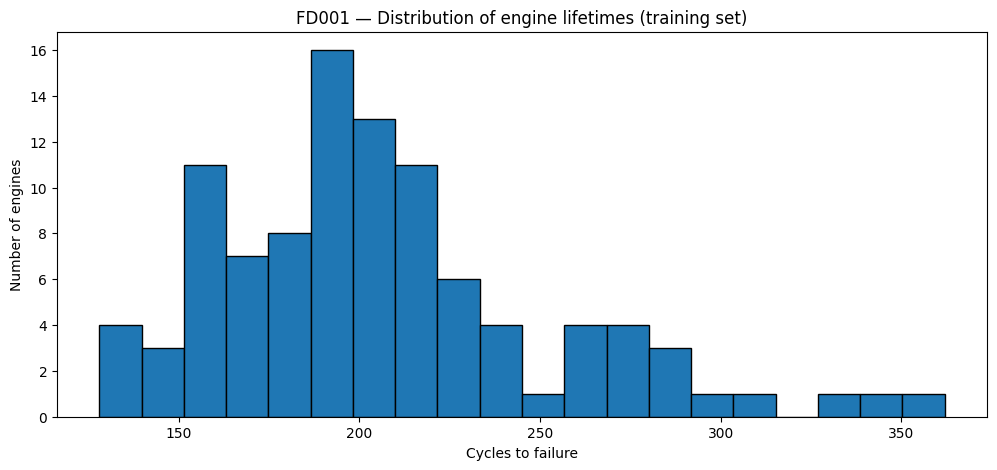

In [5]:
# For each engine, count how many cycles it ran before failing
engine_lifetimes = train_fd001.groupby('engine_id')['cycle'].max()

print(f"Lifetimes summary (cycles per engine):")
print(engine_lifetimes.describe())

# Plot the distribution
plt.figure()
plt.hist(engine_lifetimes, bins=20, edgecolor='black')
plt.xlabel('Cycles to failure')
plt.ylabel('Number of engines')
plt.title('FD001 — Distribution of engine lifetimes (training set)')
plt.show()

In [6]:
# Compute RUL for each row in training data
# Per engine: max_cycle (cycle at failure) − current_cycle = remaining cycles

train_fd001['RUL'] = (
    train_fd001.groupby('engine_id')['cycle'].transform('max')
    - train_fd001['cycle']
)

# Verify the shape didn't change and we just added a column
print(f"Shape after adding RUL: {train_fd001.shape}")
print()

# Sanity check on engine 1
engine_1 = train_fd001[train_fd001['engine_id'] == 1]
print(f"Engine 1: {len(engine_1)} cycles total")
print(f"First row (cycle 1): RUL = {engine_1.iloc[0]['RUL']}")
print(f"Last row (final cycle): RUL = {engine_1.iloc[-1]['RUL']}")
print()
print("First 3 rows of engine 1 (cycle, RUL):")
print(engine_1[['cycle', 'RUL']].head(3))
print()
print("Last 3 rows of engine 1 (cycle, RUL):")
print(engine_1[['cycle', 'RUL']].tail(3))

Shape after adding RUL: (20631, 27)

Engine 1: 192 cycles total
First row (cycle 1): RUL = 191.0
Last row (final cycle): RUL = 0.0

First 3 rows of engine 1 (cycle, RUL):
   cycle  RUL
0      1  191
1      2  190
2      3  189

Last 3 rows of engine 1 (cycle, RUL):
     cycle  RUL
189    190    2
190    191    1
191    192    0


In [7]:
# Load test sensor data — same format as train, no header, whitespace separated
test_path = DATA_RAW / 'test_FD001.txt'

test_fd001 = pd.read_csv(
    test_path,
    sep=r'\s+',
    header=None,
    names=all_cols,
)

# Load ground-truth RUL — one number per test engine, single column
rul_path = DATA_RAW / 'RUL_FD001.txt'

rul_fd001 = pd.read_csv(
    rul_path,
    sep=r'\s+',
    header=None,
    names=['RUL'],
)

print(f"Test set shape: {test_fd001.shape}")
print(f"Number of unique test engines: {test_fd001['engine_id'].nunique()}")
print()
print(f"Ground truth RUL shape: {rul_fd001.shape}")
print(f"First 5 ground-truth RUL values: {rul_fd001['RUL'].head().tolist()}")
print()

# How many cycles does each test engine have? (compare to train)
test_last_cycle = test_fd001.groupby('engine_id')['cycle'].max()
print("Test set engine cycle counts (how far into each engine's life we observed):")
print(test_last_cycle.describe())

Test set shape: (13096, 26)
Number of unique test engines: 100

Ground truth RUL shape: (100, 1)
First 5 ground-truth RUL values: [112, 98, 69, 82, 91]

Test set engine cycle counts (how far into each engine's life we observed):
count    100.000000
mean     130.960000
std       53.593479
min       31.000000
25%       88.750000
50%      133.500000
75%      164.250000
max      303.000000
Name: cycle, dtype: float64


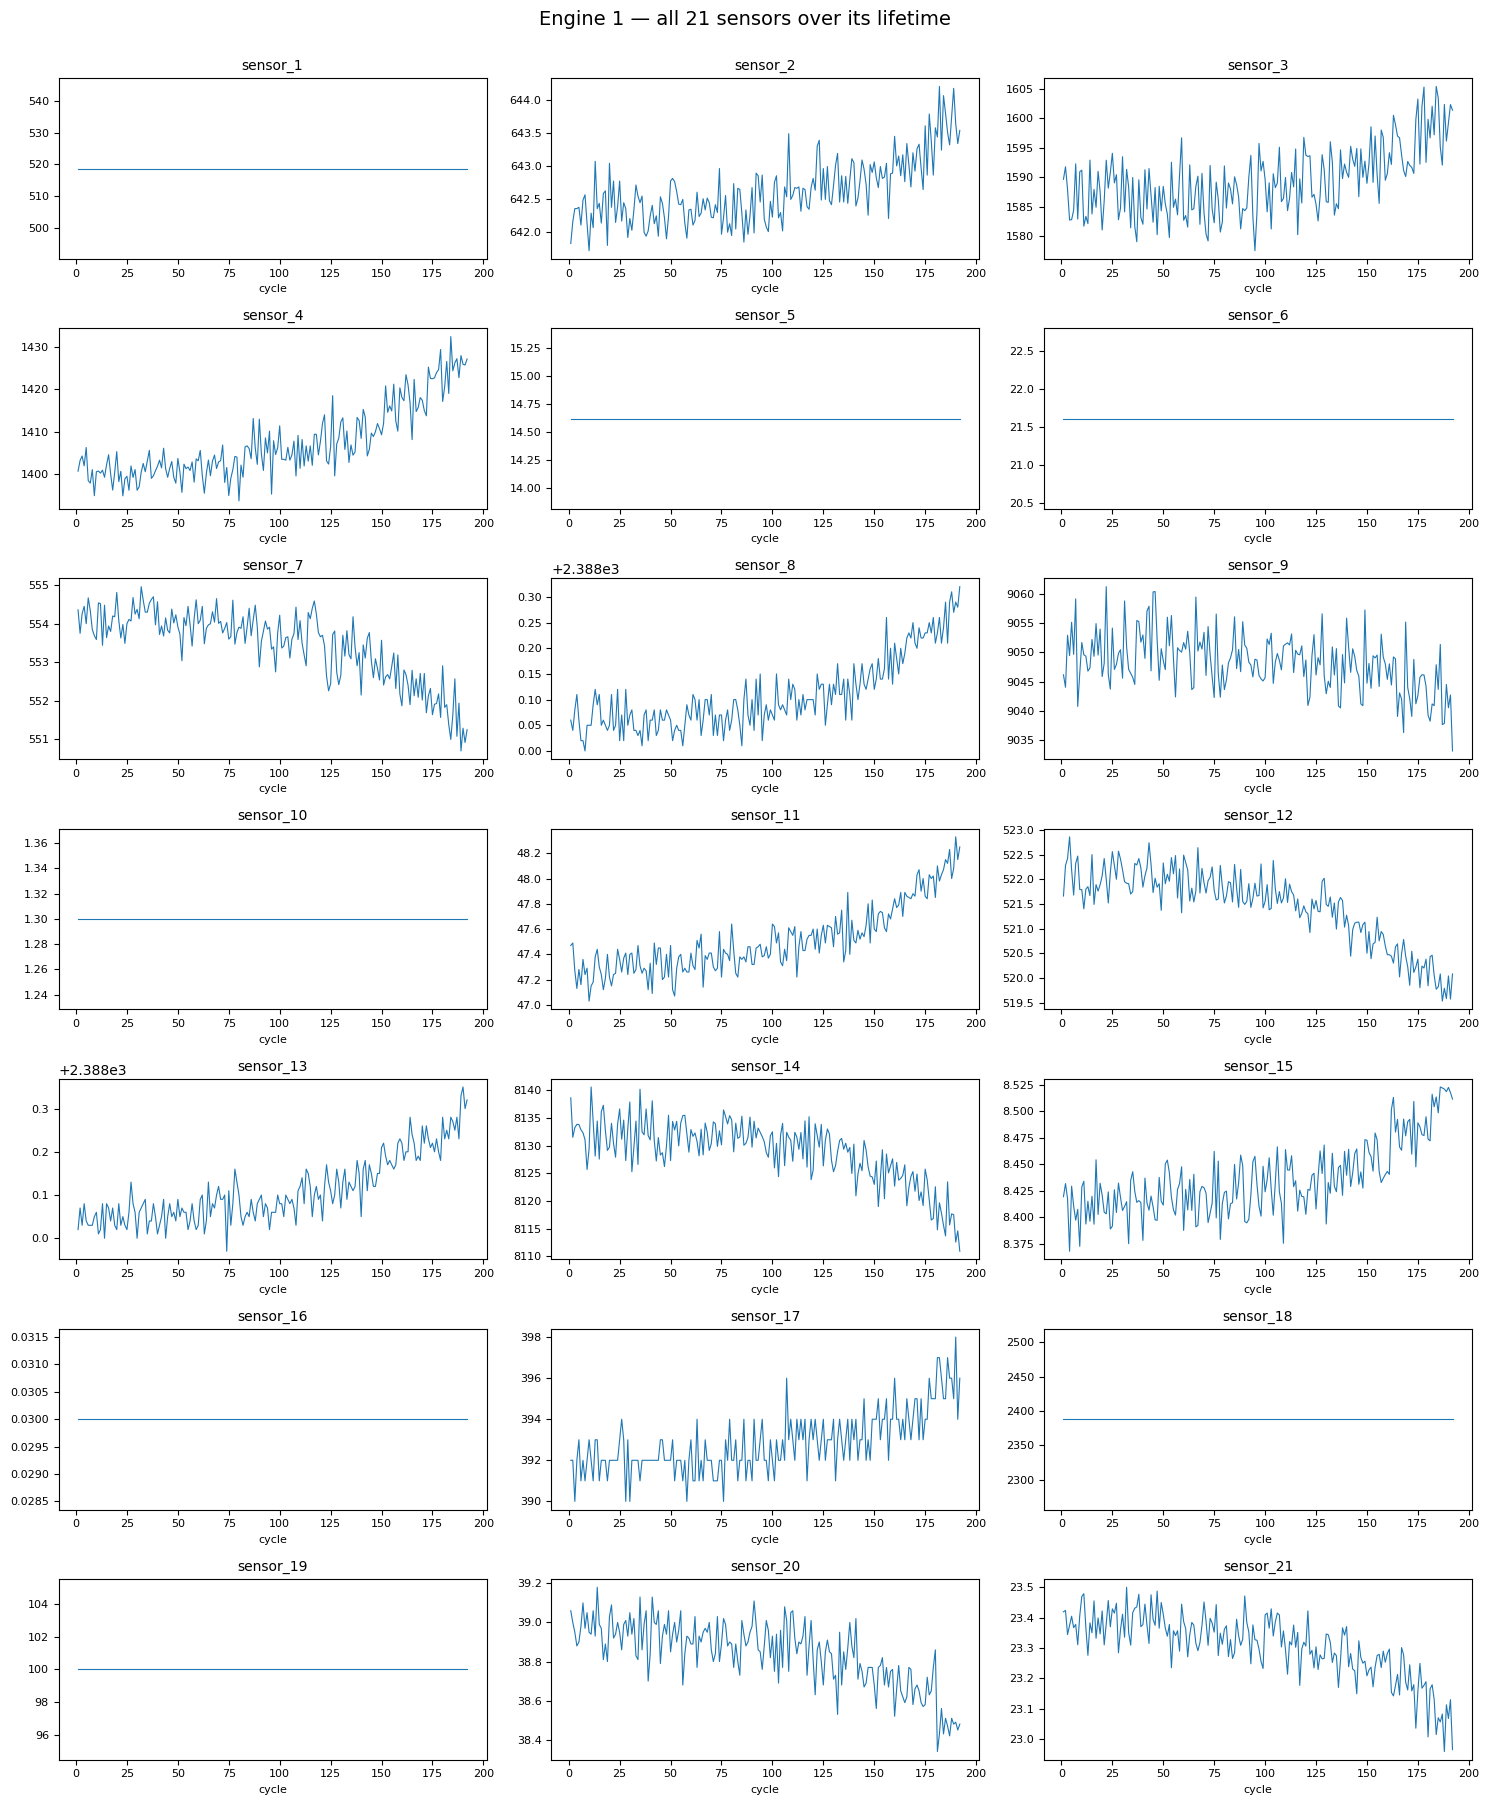

In [8]:
# Pick engine 1's full trajectory
engine_to_plot = 1
df_engine = train_fd001[train_fd001['engine_id'] == engine_to_plot]

# Create a grid of subplots — 21 sensors, arranged as 7 rows × 3 cols
fig, axes = plt.subplots(7, 3, figsize=(15, 18))
axes = axes.flatten()  # turn 7×3 grid into a flat list of 21 axes

for i, sensor in enumerate(sensor_cols):
    ax = axes[i]
    ax.plot(df_engine['cycle'], df_engine[sensor], linewidth=0.8)
    ax.set_title(sensor, fontsize=10)
    ax.set_xlabel('cycle', fontsize=8)
    ax.tick_params(labelsize=8)

plt.suptitle(f'Engine {engine_to_plot} — all 21 sensors over its lifetime', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()